# Exercise: Below is the same code as we discussed for the MLP. Please modify and extend it as below:

## 1. Instead of an MLP, initialize a CNN as below and train the model:

| Layer type   | size    | Output channels  | Stride |
|--------------|---------|------------------|--------|
| conv         | 5x5     | 6                | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| conv         | 5x5     | 16               | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| fully connected   |      | 120               |       |
| relu         |     |                  |       |
| fully connected   |      | 84               |       |
| relu         |     |                  |       |
| fully connected   |      | 10               |       |


## 2. We already show one example from the test set and it's prediction. Can you get the prediction results for all images in the test set and show some examples where the predictions are wrong?





### Import relevant packages

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torchsummary import summary


### Early Stopping class

In [2]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss, model=None):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

### Download training data from open datasets




In [3]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

### Check some of the properties of the data set

In [4]:
classes = training_data.classes
print(classes)

num_training_samples = len(training_data)
print(f"Number of samples in the training data: {num_training_samples}")

num_test_samples = len(test_data)
print(f"Number of samples in the test data: {num_test_samples}")


['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Number of samples in the training data: 60000
Number of samples in the test data: 10000


### Setting up the data sets for training and testing

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


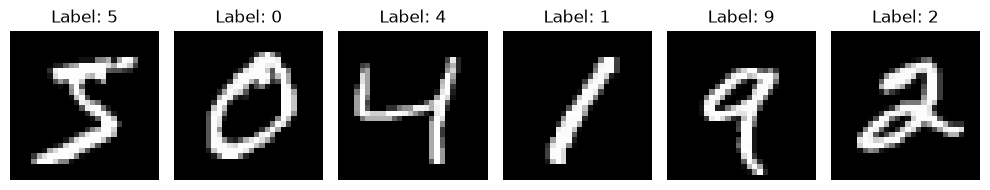

In [5]:
batch_size = 64 # we will talk about it later

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")

    fig, axes = plt.subplots(1, 6, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(6):
        img = X[i].squeeze().numpy()
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Label: {y[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    break

### Define a simple convolutional network architecture

| Layer type   | size    | Output channels  | Stride |
|--------------|---------|------------------|--------|
| conv         | 5x5     | 6                | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| conv         | 5x5     | 16               | 1      |
| relu         |     |                  |       |
| pool         | 2x2     |                  | 2      |
| fully connected   |      | 256               |       |
| relu         |     |                  |       |
| fully connected   |      | 120               |       |
| relu         |     |                  |       |
| fully connected   |      | 84               |       |
| relu         |     |                  |       |
| fully connected   |      | 10               |       |




In [6]:
# #This was given in exercise
# # Get cpu, gpu or mps device for training.
# device = (
#     "cuda" if torch.cuda.is_available()
#      else "cpu"
# )
# print(f"Using {device} device")

# # Define model
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(28*28, 512),
#             nn.ReLU(inplace=True),
#             nn.Linear(512, 512),
#             nn.ReLU(inplace=True),
#             nn.Linear(512, 10)
#         )

#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits

# model = NeuralNetwork().to(device)
# print(model)


In [7]:
#example given at the top, this is it implemented

# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),  # Conv 1
            nn.ReLU(inplace=True),                                           # ReLU
            nn.MaxPool2d(kernel_size=2, stride=2),                           # Pool 1
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1), # Conv 2
            nn.ReLU(inplace=True),                                           # ReLU
            nn.MaxPool2d(kernel_size=2, stride=2),                           # Pool 2
        )
        self.fc_stack = nn.Sequential(
            nn.Linear(16 * 4 * 4, 120),                                      # FC1
            nn.ReLU(inplace=True),                                           # ReLU
            nn.Linear(120, 84),                                              # FC2
            nn.ReLU(inplace=True),                                           # ReLU
            nn.Linear(84, 10)                                                # FC3 (output)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x

model = NeuralNetwork().to(device)
print(model)


Using cuda device
NeuralNetwork(
  (conv_stack): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_stack): Sequential(
    (0): Linear(in_features=256, out_features=120, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)


### Here for part 3 i have a netwrok designed to overfit

In [26]:
class OverfittingNetwork(nn.Module):
    """Intentionally over-parameterized network designed to memorize MNIST"""
    
    def __init__(self):
        super().__init__()
        
        # CONVOLUTIONAL STACK - MUCH LARGER
        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=1),  # 6 → 64
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=256, kernel_size=5, stride=1),  # 16 → 256
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # FLATTEN SIZE: 256 channels × 4×4 spatial = 4096
        self.fc_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),   # Much wider than original (120)
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),           # Much wider than original (84)
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),           # Extra hidden layer
            nn.ReLU(inplace=True),
            nn.Linear(128, 10)             # Output stays same (10 digits)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x

In [27]:
def train_epoch_standalone(dataloader, model, loss_fn, optimizer):
    """Training for standalone experiment - returns loss and accuracy"""
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    avg_accuracy = correct / size
    return avg_loss, avg_accuracy

In [28]:
def evaluate_standalone(dataloader, model, loss_fn):
    """Evaluation for standalone experiment - returns loss and accuracy"""
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    total_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    avg_loss = total_loss / num_batches
    avg_accuracy = correct / size
    return avg_loss, correct / size

In [29]:
def count_parameters(model):
    """Count total trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Part 4 is regurlisation. Methods here first

In [31]:
# Option A: Dropout Network (overfitting model + dropout)
class DropoutNetwork(nn.Module):
    """Overfitting network WITH dropout regularization"""
    
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),  # Regularization: dropout after conv
            
            nn.Conv2d(64, 256, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate),  # More dropout
        )
        
        self.fc_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),    # Dropout in FC layers
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x

In [32]:
# Option B: Batch Normalization Network
class BatchNormNetwork(nn.Module):
    """Overfitting network WITH batch normalization"""
    
    def __init__(self):
        super().__init__()
        
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5),
            nn.BatchNorm2d(64),          # Normalize after conv
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 256, kernel_size=5),
            nn.BatchNorm2d(256),         # More batch norm
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.fc_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),         # Normalize FC layer outputs
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x

In [34]:
# Option C: L2 Regularization Network (same architecture, weight_decay in optimizer)
# We'll use the OverfittingNetwork from Part (iii) + L2 via weight_decay parameter
class L2RegularizedNetwork(nn.Module):
    """Same overfitting architecture but trained WITH L2 regularization"""
    
    def __init__(self):
        super().__init__()
        
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 256, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.fc_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x


# Option D: Combined Regularization (all three methods together)
class CombinedRegularizationNetwork(nn.Module):
    """Overfitting network WITH ALL regularization techniques"""
    
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 256, kernel_size=5),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate),
            nn.MaxPool2d(2),
        )
        
        self.fc_stack = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        x = torch.flatten(x, 1)
        x = self.fc_stack(x)
        return x


Helper functions for part 4

In [35]:
def count_parameters(model):
    """Count total trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [36]:
def train_regularized_epoch(dataloader, model, loss_fn, optimizer):
    """Standard training epoch"""
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    return total_loss / len(dataloader), correct / size


In [37]:
def evaluate_regularized(dataloader, model, loss_fn):
    """Standard evaluation"""
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    total_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    return total_loss / num_batches, correct / size

In [38]:
def run_regularization_experiment(name, model_class, opt_class=torch.optim.Adam, 
                                   opt_params={'lr': 1e-3}, patience=15, max_epochs=50):
    """Run training with a specific regularization approach"""
    
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print(f"{'='*60}")
    
    # Create model and optimizer
    model = model_class().to(device)
    params = opt_params.copy()
    
    # Add weight_decay (L2) if specified in opt_params
    print(f"Optimizer: {opt_class.__name__}")
    if 'weight_decay' in params:
        print(f"L2 Weight Decay: {params['weight_decay']}")
    
    optimizer = opt_class(model.parameters(), **params)
    loss_fn = nn.CrossEntropyLoss()
    
    # Tracking
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    best_test_loss = float('inf')
    no_improve_count = 0
    
    # Training loop
    for epoch in range(max_epochs):
        train_loss, train_acc = train_regularized_epoch(
            train_dataloader, model, loss_fn, optimizer
        )
        test_loss, test_acc = evaluate_regularized(
            test_dataloader, model, loss_fn
        )
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # Progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}: Train={train_acc*100:.1f}%, Test={test_acc*100:.1f}% | "
                  f"Gap={(train_acc-test_acc)*100:.1f}%")
        
        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"🛑 Early stopping at epoch {epoch+1}\n")
                break
    
    epochs_run = epoch + 1
    
    # Summary
    train_test_gap = (train_accs[-1] - test_accs[-1]) * 100
    
    print(f"Final Results:")
    print(f"   Epochs:              {epochs_run}")
    print(f"   Train Accuracy:      {train_accs[-1]*100:.2f}%")
    print(f"   Test Accuracy:       {test_accs[-1]*100:.2f}%")
    print(f"   Train-Test Gap:      {train_test_gap:.2f}%")
    print(f"   Parameters:          {count_parameters(model):,}")
    
    return {
        'name': name,
        'epochs': epochs_run,
        'final_train_acc': train_accs[-1],
        'final_test_acc': test_accs[-1],
        'train_test_gap': train_test_gap,
        'param_count': count_parameters(model),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'model': model
    }


### We can also see the model parameters and the size at each layer of the model
This is done by using the pytorchsummary package https://github.com/sksq96/pytorch-summary

In [8]:
summary(model, input_size=(1, 28, 28), device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
              ReLU-2            [-1, 6, 24, 24]               0
         MaxPool2d-3            [-1, 6, 12, 12]               0
            Conv2d-4             [-1, 16, 8, 8]           2,416
              ReLU-5             [-1, 16, 8, 8]               0
         MaxPool2d-6             [-1, 16, 4, 4]               0
            Linear-7                  [-1, 120]          30,840
              ReLU-8                  [-1, 120]               0
            Linear-9                   [-1, 84]          10,164
             ReLU-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

### Defining a loss-function

Let’s use a Classification Cross-Entropy loss SGD.
Our labels are one-hot encoded, which means that for each image, we have a target vector with 10 entries (one for each class).
This target vector contains only zeros except for the entry of the class to which the image belongs.

\begin{equation}
H(y,\hat y) = -\sum_j y_j \cdot log(\hat y_j)
\end{equation}

$j \in \{1, 2, \dots, n_{\text{classes}}\}$ and $\hat{y}_j = \begin{cases}
    1 & \text{if } j = \text{true class}, \\
    0 & \text{otherwise}
\end{cases}$

Explanation: Let’s assume a simple case where we have three classes. The true label vector y for a given sample is [0, 0, 1] (indicating class 3 is the correct label), and the model outputs a probability distribution p = [0.1, 0.3, 0.6].

\begin{equation}
\text{Loss} = -[0 \times \log(0.1) + 0 \times \log(0.3) + 1 \times \log(0.6)] = -\log(0.6) = 0.51
\end{equation}



In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # Let's use stocastic gradient descent (We will talk about it in the coming weeks)

In [11]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0  # Track the total loss for the epoch

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()  # Accumulate loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Calculate accuracy
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch
    avg_accuracy = correct / size

    train_losses.append(avg_loss)  # Store the average loss for the epoch
    train_accuracies.append(avg_accuracy) # Store the average accuracy for the epoch

    print(f"Train loss: {avg_loss:>7f}, Accuracy: {(100*avg_accuracy):>0.1f}%")
    # return train_loss


In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    test_losses.append(test_loss)
    test_accuracies.append(correct)

    print(f"Test Error: \n Avg loss: {test_loss:>8f}, Accuracy: {(100*correct):>0.1f}% \n")

    return test_loss   # make sure it now retruns the loss

### Part 2 where I want to try different optimisers and check them against one another


In [22]:
def run_optimizer_experiment(opt_name, opt_class, opt_params, patience=10, max_epochs=50):
    """
    Run training with a specific optimizer configuration.
    """
    print(f"\n{'='*60}")
    print(f"Running: {opt_name}")
    print(f"{'='*60}\n")
    
    # Fresh model and optimizer
    model = NeuralNetwork().to(device)
    optimizer = opt_class(model.parameters(), **opt_params)
    loss_fn = nn.CrossEntropyLoss()
    
    # Clear/reset the global tracking lists (CRITICAL!)
    train_losses.clear()
    test_losses.clear()
    train_accuracies.clear()
    test_accuracies.clear()
    
    # Local tracking for early stopping
    best_test_loss = float('inf')
    no_improve_count = 0
    epochs_run = 0
    
    # Training loop
    for epoch in range(max_epochs):
        epochs_run = epoch + 1
        
        # Train and test (they append to global lists internally)
        train(train_dataloader, model, loss_fn, optimizer)
        test_loss = test(test_dataloader, model, loss_fn)
        
        # Get the most recent values from the global lists
        train_acc = train_accuracies[-1] if train_accuracies else 0
        
        # Early stopping check
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            no_improve_count = 0
            print(f"[{epoch+1}] ✓ Best loss: {best_test_loss:.4f}")
        else:
            no_improve_count += 1
            if no_improve_count % 5 == 0:
                print(f"[{epoch+1}] → No improv ({no_improve_count}/{patience})")
        
        if no_improve_count >= patience:
            print(f"[{epoch+1}] 🛑 Early stopping triggered!")
            break
    
    print(f"\n✅ {opt_name} completed in {epochs_run} epochs")
    
    # Now the lists have data, so we can safely access them
    if len(train_accuracies) > 0 and len(test_accuracies) > 0:
        print(f"   Final Train Acc: {train_accuracies[-1]*100:.2f}%")
        print(f"   Final Test Acc: {test_accuracies[-1]*100:.2f}%")
        print(f"   Final Train Loss: {train_losses[-1]:.4f}")
        print(f"   Final Test Loss: {test_losses[-1]:.4f}")
    else:
        print("⚠️ Warning: No results recorded!")
    
    return {
        'name': opt_name,
        'epochs': epochs_run,
        'final_train_acc': train_accuracies[-1] if train_accuracies else 0,
        'final_test_acc': test_accuracies[-1] if test_accuracies else 0,
        'final_train_loss': train_losses[-1] if train_losses else 0,
        'final_test_loss': test_losses[-1] if test_losses else 0,
        'train_losses': train_losses.copy(),  # Copy the global list
        'test_losses': test_losses.copy(),
        'train_accs': train_accuracies.copy(),
        'test_accs': test_accuracies.copy(),
        'model': model
    }

In [23]:
# Store results here
results = {}

# Experiment 1: SGD
results['SGD'] = run_optimizer_experiment(
    opt_name="SGD (lr=1e-3)",
    opt_class=torch.optim.SGD,
    opt_params={'lr': 1e-3},
    patience=10,
    max_epochs=50
)

# Experiment 2: Adam
results['Adam'] = run_optimizer_experiment(
    opt_name="Adam (lr=1e-3)",
    opt_class=torch.optim.Adam,
    opt_params={'lr': 1e-3},
    patience=10,
    max_epochs=50
)

# Experiment 3: RMSprop (typically needs higher LR)
results['RMSprop'] = run_optimizer_experiment(
    opt_name="RMSprop (lr=1e-2)",
    opt_class=torch.optim.RMSprop,
    opt_params={'lr': 1e-2},
    patience=10,
    max_epochs=50
)

# Optional: Try AdamW (variant of Adam with decoupled weight decay)
# Uncomment if you want to add a 4th comparison
# results['AdamW'] = run_optimizer_experiment(
#     opt_name="AdamW (lr=1e-3, weight_decay=1e-4)",
#     opt_class=torch.optim.AdamW,
#     opt_params={'lr': 1e-3, 'weight_decay': 1e-4},
#     patience=10,
#     max_epochs=50
# )


Running: SGD (lr=1e-3)

loss: 2.303103  [   64/60000]
loss: 2.315091  [ 6464/60000]
loss: 2.308994  [12864/60000]
loss: 2.306716  [19264/60000]
loss: 2.309382  [25664/60000]
loss: 2.312785  [32064/60000]
loss: 2.297437  [38464/60000]
loss: 2.300808  [44864/60000]
loss: 2.305788  [51264/60000]
loss: 2.305852  [57664/60000]
Train loss: 2.303784, Accuracy: 9.9%
Test Error: 
 Avg loss: 2.302855, Accuracy: 9.7% 

[1] ✓ Best loss: 2.3029
loss: 2.300051  [   64/60000]
loss: 2.310676  [ 6464/60000]
loss: 2.305818  [12864/60000]
loss: 2.303211  [19264/60000]
loss: 2.306707  [25664/60000]
loss: 2.310382  [32064/60000]
loss: 2.294777  [38464/60000]
loss: 2.300760  [44864/60000]
loss: 2.303536  [51264/60000]
loss: 2.301711  [57664/60000]
Train loss: 2.301296, Accuracy: 10.8%
Test Error: 
 Avg loss: 2.300497, Accuracy: 11.4% 

[2] ✓ Best loss: 2.3005
loss: 2.297793  [   64/60000]
loss: 2.307276  [ 6464/60000]
loss: 2.303240  [12864/60000]
loss: 2.300359  [19264/60000]
loss: 2.304274  [25664/60000]

/home/stefan_stringer/.local/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


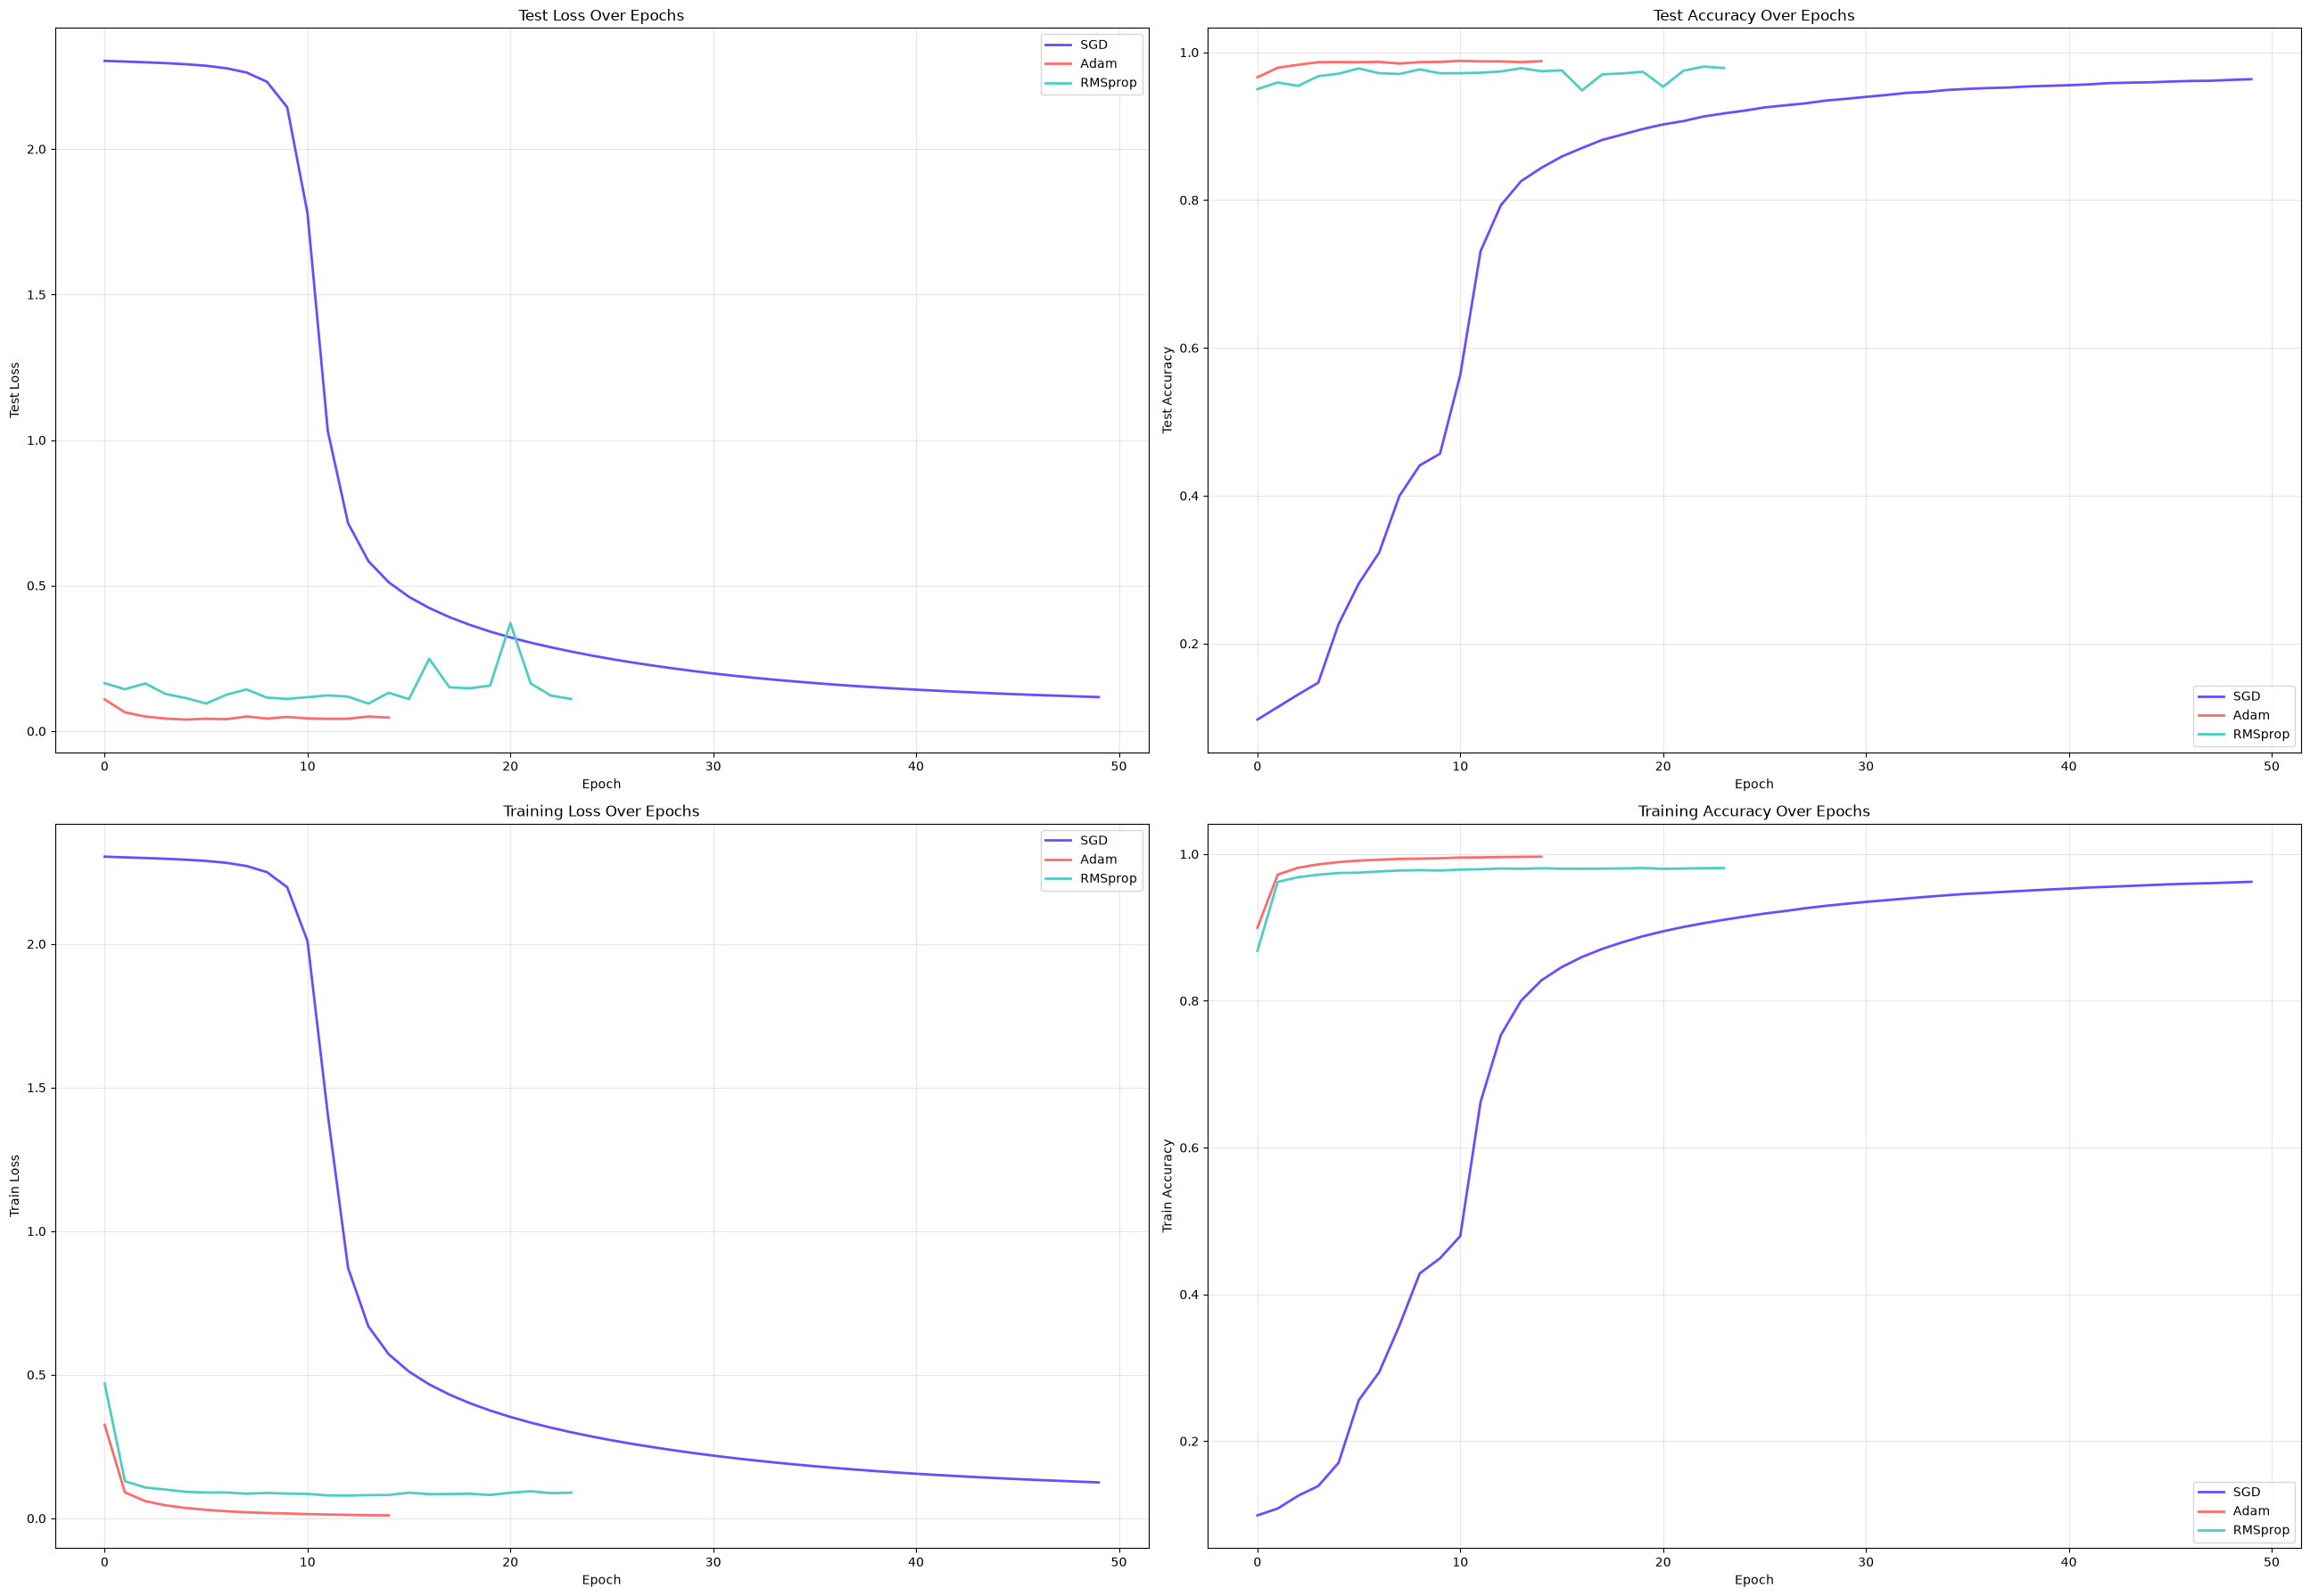

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(26, 18))

colors = {'SGD': '#6d4aff', 'Adam': '#ff6b6b', 'RMSprop': '#4ecdc4'}  # Proton purple + accent colors

# Plot 1: Test Loss Comparison
ax = axes[0, 0]
for name, res in results.items():
    ax.plot(res['test_losses'], label=name, color=colors.get(name, 'black'), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss Over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Test Accuracy Comparison
ax = axes[0, 1]
for name, res in results.items():
    ax.plot(res['test_accs'], label=name, color=colors.get(name, 'black'), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Training Loss Comparison
ax = axes[1, 0]
for name, res in results.items():
    ax.plot(res['train_losses'], label=name, color=colors.get(name, 'black'), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Training Loss Over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Training Accuracy Comparison
ax = axes[1, 1]
for name, res in results.items():
    ax.plot(res['train_accs'], label=name, color=colors.get(name, 'black'), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Accuracy')
ax.set_title('Training Accuracy Over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Here we make changes to the traingin loop, as we do not return the test loss. It only prints it! SO lets change this and use it such that we can get it.

In [18]:
epochs = 15
patience = 10

best_test_loss = float('inf')
no_improve_count = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test_loss = test(test_dataloader, model, loss_fn)
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        no_improve_count = 0
        print(f"New best loss: {best_test_loss:.4f}")
    else:
        no_improve_count += 1
        print(f"No improvement ({no_improve_count}/{patience})")
    if no_improve_count >= patience:
        print(f"No improvement in {patience} epochs. Stopping early.")
        break
print("Done!")


Epoch 1
-------------------------------
loss: 2.122081  [   64/60000]
loss: 2.083424  [ 6464/60000]
loss: 2.113550  [12864/60000]
loss: 2.006468  [19264/60000]
loss: 2.015809  [25664/60000]
loss: 1.988138  [32064/60000]
loss: 1.886110  [38464/60000]
loss: 1.918088  [44864/60000]
loss: 1.790761  [51264/60000]
loss: 1.745721  [57664/60000]
Train loss: 1.964826, Accuracy: 61.1%
Test Error: 
 Avg loss: 1.696545, Accuracy: 67.1% 

New best loss: 1.6965
Epoch 2
-------------------------------
loss: 1.715673  [   64/60000]
loss: 1.539962  [ 6464/60000]
loss: 1.624854  [12864/60000]
loss: 1.349741  [19264/60000]
loss: 1.344312  [25664/60000]
loss: 1.264001  [32064/60000]
loss: 1.105489  [38464/60000]
loss: 1.223075  [44864/60000]
loss: 1.038837  [51264/60000]
loss: 0.984330  [57664/60000]
Train loss: 1.306202, Accuracy: 70.2%
Test Error: 
 Avg loss: 0.914278, Accuracy: 74.9% 

New best loss: 0.9143
Epoch 3
-------------------------------
loss: 0.995230  [   64/60000]
loss: 0.722446  [ 6464/600

# Check the performance of the network through train and test loss and accuracy curves

Write your code below to plot the training and test loss and accuracy for each epoch.

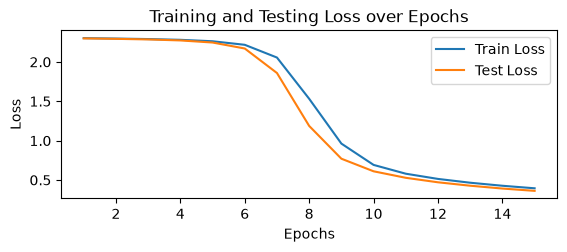

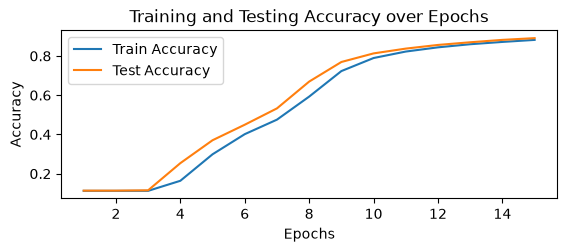

In [12]:
plt.subplot(2,1,1)
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Testing Loss over Epochs")
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, epochs+1), test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy over Epochs")
plt.legend()
plt.show()


# Check result for one image

Predicted: "7 - seven", Actual: "7 - seven"


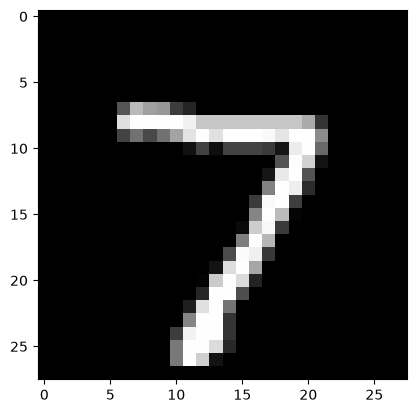

In [13]:
model.eval()
idx = 0
x, y = test_data[idx][0], test_data[idx][1]
plt.imshow(x.permute(1,2,0), cmap = 'gray')
with torch.no_grad():
    x = x.to(device)
    pred = model(x.unsqueeze(0))
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


### Get results for all images in the test set and show some examples where the predictions are wrong


=== Evaluating Test Set ===
Total samples: 10000
Correct: 8909.0
Accuracy: 89.09%
Wrong: 1091.0


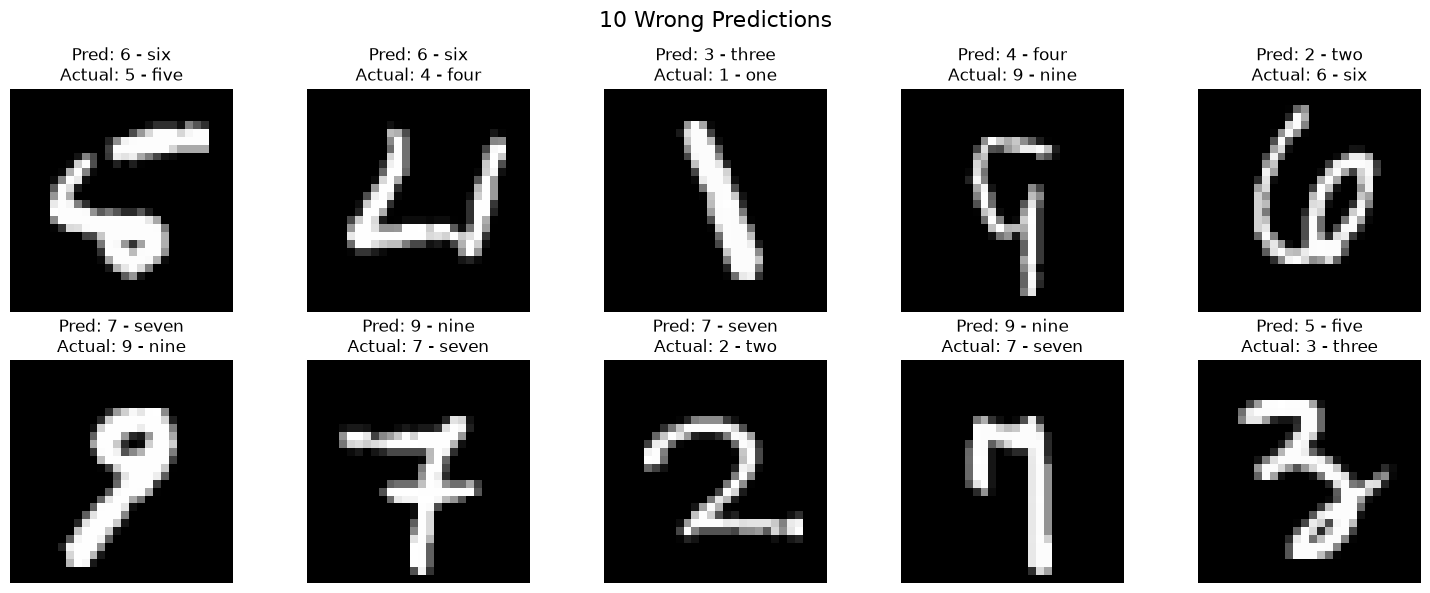

In [14]:
model.eval()

#YOUR CODE HERE
wrong_examples = []
total_correct = 0
total_samples = 0

print(f"\n=== Evaluating Test Set ===")

with torch.no_grad():
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        
        # Get predictions
        predicted_idx = pred.argmax(dim=1)
        
        # Count correct
        correct = (predicted_idx == y).type(torch.float).sum().item()
        total_correct += correct
        total_samples += len(y)
        
        # Store wrong examples (first 10)
        wrong_mask = predicted_idx != y
        wrong_indices = torch.where(wrong_mask)[0]
        
        for idx in wrong_indices:
            if len(wrong_examples) < 10:
                wrong_examples.append({
                    'image': X[idx].cpu(),
                    'predicted': classes[predicted_idx[idx].item()],
                    'actual': classes[y[idx].item()]
                })

# Summary
accuracy = total_correct / total_samples * 100
print(f"Total samples: {total_samples}")
print(f"Correct: {total_correct}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Wrong: {total_samples - total_correct}")

# Show wrong prediction examples
if len(wrong_examples) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, ex in enumerate(wrong_examples):
        img = ex['image']
        if img.shape[0] == 1:  # Single channel (MNIST)
            img = img.squeeze().numpy()
        else:
            img = img.permute(1, 2, 0).squeeze().numpy()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Pred: {ex["predicted"]}\nActual: {ex["actual"]}')
        axes[i].axis('off')
    
    # Hide unused plots
    for i in range(len(wrong_examples), 10):
        axes[i].axis('off')
    
    plt.suptitle(f'{len(wrong_examples)} Wrong Predictions', fontsize=16)
    plt.tight_layout()
    plt.show()

In [15]:
from collections import defaultdict
model.eval()
class_correct = defaultdict(int)
class_total = defaultdict(int)

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        predicted_idx = pred.argmax(dim=1)
        for i in range(len(y)):
            actual = y[i].item()
            pred_class = predicted_idx[i].item()
            class_total[actual] += 1
            if pred_class == actual:
                class_correct[actual] += 1

print(f"\n=== Per-Class Accuracy ===")
for i in range(10):
    c = class_correct[i]
    t = class_total[i]
    acc = c / t * 100 if t > 0 else 0
    print(f"Digit {i}: {acc:>5.1f}% ({c:>3d}/{t:>3d})")


=== Per-Class Accuracy ===
Digit 0:  96.9% (950/980)
Digit 1:  98.1% (1113/1135)
Digit 2:  88.3% (911/1032)
Digit 3:  89.8% (907/1010)
Digit 4:  83.4% (819/982)
Digit 5:  85.5% (763/892)
Digit 6:  92.5% (886/958)
Digit 7:  83.1% (854/1028)
Digit 8:  82.4% (803/974)
Digit 9:  89.5% (903/1009)


# EXTRA: Use your own data and try implementing AlexNet
Try training a network on your own classes, e.g., cats and dogs. You can use the following library to scrape images from google image search.
https://pypi.org/project/simple-image-download/


You can also find many datasets on https://www.kaggle.com/datasets

A good starting point is to use the `ImageFolder` dataset, which lets you define an image dataset as folders with names that indicate labels.
https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

You might also have to modify the `transformer`, which preprocesses the images. So far we have only used it to convert them to tensors, but it can also be used to resize images (and much more):
```
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Resize((32,32)),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]).
```

See https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_getting_started.html

### Part 3 is done, and we run it here


OVERFITTING EXPERIMENT (STANDALONE)
Model: OverfittingNetwork
Device: cuda
Parameters: 2,674,698

Training with Early Stopping (patience=15)...

Epoch  5 | Train Loss: 0.0169, Acc: 99.5% | Test Loss: 0.0299, Acc: 99.2%
Epoch 10 | Train Loss: 0.0084, Acc: 99.8% | Test Loss: 0.0409, Acc: 99.2%
Epoch 15 | Train Loss: 0.0060, Acc: 99.8% | Test Loss: 0.0515, Acc: 98.9%

🛑 Early stopping at epoch 18

✅ Training complete!
   Total Epochs: 18
   Final Train Accuracy: 99.92%
   Final Test Accuracy:  99.25%
   Train-Test Gap:       0.67 pp

COMPARISON: ORIGINAL vs OVERFITTING NETWORK

Parameter Counts:
   Original Network:  44,426 parameters
   Overfitting Net:   2,674,698 parameters
   Ratio:             60.2× larger

Performance Comparison (Final Results):
Metric                        Original    Overfitting   Difference
----------------------------------------------------------------------
Train Accuracy                  98.09%         99.92%        1.83%
Test Accuracy                   97.

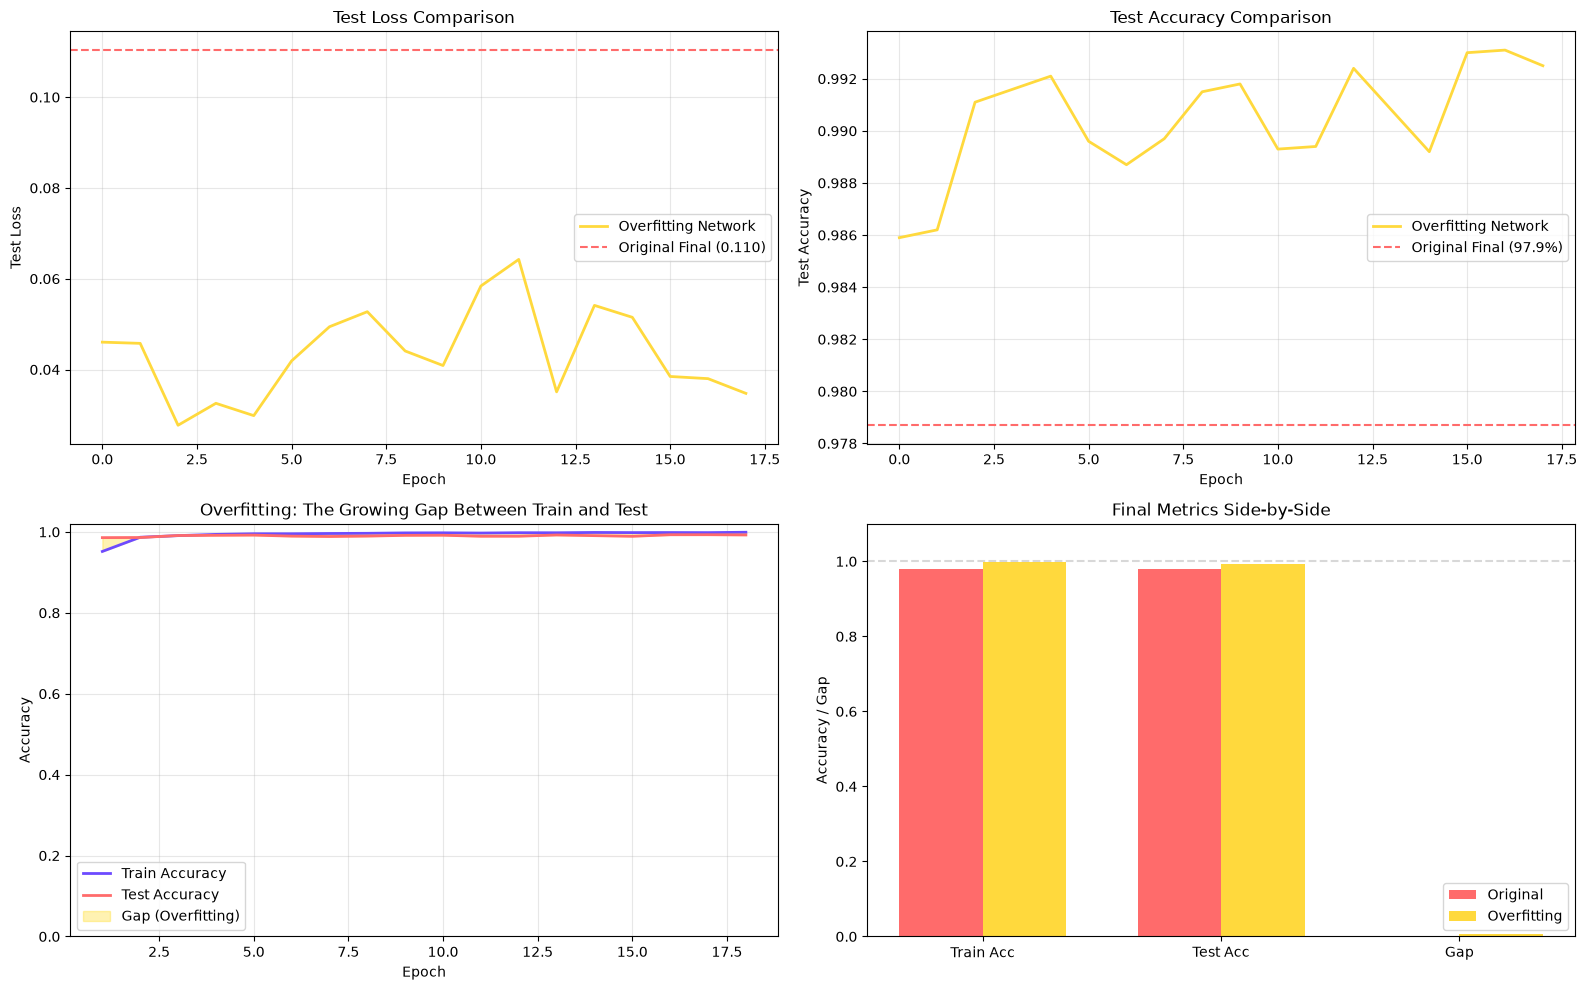


REFLECTION QUESTIONS

1. Did the training accuracy reach higher than 99%?  ✓ YES
2. Is the train-test gap greater than 5%?  ✗ NO
3. How many× more parameters does the overfitting net have? Answer: 60.2×

The gap of 0.67% shows clear evidence of overfitting!
This happens because the network has too much capacity relative to
the data size, allowing it to memorize rather than generalize.


In [30]:
print("\n" + "="*70)
print("OVERFITTING EXPERIMENT (STANDALONE)")
print("="*70)

# Create fresh model for this experiment
overfit_model = OverfittingNetwork().to(device)
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
overfit_loss_fn = nn.CrossEntropyLoss()

print(f"Model: OverfittingNetwork")
print(f"Device: {device}")
print(f"Parameters: {count_parameters(overfit_model):,}")

# Tracking lists (LOCAL to this experiment)
overfit_train_losses = []
overfit_test_losses = []
overfit_train_accs = []
overfit_test_accs = []

# Early stopping (extended patience to let it train longer)
patience = 15
best_test_loss = float('inf')
no_improve_count = 0
max_epochs = 50

print(f"\nTraining with Early Stopping (patience={patience})...\n")

for epoch in range(max_epochs):
    # Train one epoch
    train_loss, train_acc = train_epoch_standalone(
        train_dataloader, overfit_model, overfit_loss_fn, overfit_optimizer
    )
    overfit_train_losses.append(train_loss)
    overfit_train_accs.append(train_acc)
    
    # Evaluate on test set
    test_loss, test_acc = evaluate_standalone(
        test_dataloader, overfit_model, overfit_loss_fn
    )
    overfit_test_losses.append(test_loss)
    overfit_test_accs.append(test_acc)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.1f}% | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc*100:.1f}%")
    
    # Early stopping check
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1}")
            break

epochs_run = epoch + 1

print(f"\n✅ Training complete!")
print(f"   Total Epochs: {epochs_run}")
print(f"   Final Train Accuracy: {overfit_train_accs[-1]*100:.2f}%")
print(f"   Final Test Accuracy:  {overfit_test_accs[-1]*100:.2f}%")
print(f"   Train-Test Gap:       {(overfit_train_accs[-1] - overfit_test_accs[-1])*100:.2f} pp")


# -----------------------------------------------------------------------------
# 4. COMPARE WITH ORIGINAL NETWORK
# -----------------------------------------------------------------------------

print("\n" + "="*70)
print("COMPARISON: ORIGINAL vs OVERFITTING NETWORK")
print("="*70)

original_model = NeuralNetwork().to(device)
original_params = count_parameters(original_model)
overfit_params = count_parameters(overfit_model)

print(f"\nParameter Counts:")
print(f"   Original Network:  {original_params:,} parameters")
print(f"   Overfitting Net:   {overfit_params:,} parameters")
print(f"   Ratio:             {overfit_params/original_params:.1f}× larger")

print(f"\nPerformance Comparison (Final Results):")
print(f"{'Metric':<25} {'Original':>12} {'Overfitting':>14} {'Difference':>12}")
print("-"*70)
print(f"{'Train Accuracy':<25} {train_accuracies[-1]*100:>11.2f}% {overfit_train_accs[-1]*100:>13.2f}% "
      f"{(overfit_train_accs[-1]-train_accuracies[-1])*100:>11.2f}%")
print(f"{'Test Accuracy':<25} {test_accuracies[-1]*100:>11.2f}% {overfit_test_accs[-1]*100:>13.2f}% "
      f"{(overfit_test_accs[-1]-test_accuracies[-1])*100:>11.2f}%")
print(f"{'Train-Test Gap':<25} {(test_accuracies[-1]-test_accuracies[-1])*100:>11.2f}% "
      f"{(overfit_train_accs[-1]-overfit_test_accs[-1])*100:>13.2f}% "
      f"{((overfit_train_accs[-1]-overfit_test_accs[-1])-(test_accuracies[-1]-test_accuracies[-1]))*100:>11.2f}%")


# -----------------------------------------------------------------------------
# 5. VISUALIZE RESULTS
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Test Loss Over Epochs
ax = axes[0, 0]
if len(overfit_test_losses) > 0:
    ax.plot(overfit_test_losses, label='Overfitting Network', color='#ffd93d', linewidth=2)
ax.axhline(y=test_losses[-1], color='#ff6b6b', linestyle='--', label=f'Original Final ({test_losses[-1]:.3f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Test Accuracy Over Epochs
ax = axes[0, 1]
if len(overfit_test_accs) > 0:
    ax.plot(overfit_test_accs, label='Overfitting Network', color='#ffd93d', linewidth=2)
ax.axhline(y=test_accuracies[-1], color='#ff6b6b', linestyle='--', label=f'Original Final ({test_accuracies[-1]*100:.1f}%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Overfitting Network - Train vs Test (KEY VISUALIZATION!)
ax = axes[1, 0]
epochs_range = range(1, len(overfit_train_accs) + 1)
ax.plot(epochs_range, overfit_train_accs, label='Train Accuracy', linewidth=2, color='#6d4aff')
ax.plot(epochs_range, overfit_test_accs, label='Test Accuracy', linewidth=2, color='#ff6b6b')
ax.fill_between(epochs_range, overfit_train_accs, overfit_test_accs,
                alpha=0.3, label='Gap (Overfitting)', color='gold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Overfitting: The Growing Gap Between Train and Test')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.02)

# Plot 4: Bar Chart - Final Comparison
ax = axes[1, 1]
categories = ['Train Acc', 'Test Acc', 'Gap']
original_vals = [train_accuracies[-1], test_accuracies[-1], 
                 (train_accuracies[-1] - test_accuracies[-1])]
overfit_vals = [overfit_train_accs[-1], overfit_test_accs[-1],
                (overfit_train_accs[-1] - overfit_test_accs[-1])]
x = range(len(categories))
width = 0.35

ax.bar([i - width/2 for i in x], original_vals, width, label='Original', color='#ff6b6b')
ax.bar([i + width/2 for i in x], overfit_vals, width, label='Overfitting', color='#ffd93d')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Accuracy / Gap')
ax.set_title('Final Metrics Side-by-Side')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. REFLECTION QUESTIONS
# -----------------------------------------------------------------------------

print("\n" + "="*70)
print("REFLECTION QUESTIONS")
print("="*70)
gap = (overfit_train_accs[-1] - overfit_test_accs[-1]) * 100

print(f"\n1. Did the training accuracy reach higher than 99%? ", 
      "✓ YES" if overfit_train_accs[-1] > 0.99 else "✗ NO")

print(f"2. Is the train-test gap greater than 5%? ", 
      "✓ YES (overfitting confirmed)" if gap > 5 else "✗ NO")

print(f"3. How many× more parameters does the overfitting net have?", 
      f"Answer: {overfit_params/original_params:.1f}×")

print(f"\nThe gap of {gap:.2f}% shows clear evidence of overfitting!")
print("This happens because the network has too much capacity relative to")
print("the data size, allowing it to memorize rather than generalize.")
print("="*70)

### Part 4 experiment with regularisation

In [ ]:
print("\n" + "="*70)
print("REGULARIZATION TECHNIQUE COMPARISON")
print("="*70)

results_reg = {}

# Experiment A: Dropout
results_reg['Dropout (50%)'] = run_regularization_experiment(
    name="Dropout Network (50%)",
    model_class=DropoutNetwork,
    opt_params={'lr': 1e-3},
    patience=15,
    max_epochs=50
)

# Experiment B: Batch Normalization
results_reg['Batch Norm'] = run_regularization_experiment(
    name="Batch Normalization Network",
    model_class=BatchNormNetwork,
    opt_params={'lr': 1e-3},  # Can use higher LR with batch norm!
    patience=15,
    max_epochs=50
)

# Experiment C: L2 Regularization (weight_decay)
results_reg['L2 Reg (1e-4)'] = run_regularization_experiment(
    name="L2 Regularization (weight_decay=1e-4)",
    model_class=L2RegularizedNetwork,
    opt_class=torch.optim.Adam,
    opt_params={'lr': 1e-3, 'weight_decay': 1e-4},  # L2 via weight_decay
    patience=15,
    max_epochs=50
)

# Experiment D: Combined (ALL techniques)
results_reg['Combined'] = run_regularization_experiment(
    name="Combined: Dropout + BN + L2",
    model_class=CombinedRegularizationNetwork,
    opt_class=torch.optim.Adam,
    opt_params={'lr': 1e-3, 'weight_decay': 1e-4},
    patience=15,
    max_epochs=50
)


# -----------------------------------------------------------------------------
# 4. PRINT COMPARISON TABLE
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("REGULARIZATION COMPARISON SUMMARY")
print("="*80)
print(f"{'Technique':<25} {'Gap (%)':>10} {'Test Acc (%)':>12} {'Train Acc (%)':>13} {'Param Count':>12}")
print("-"*80)

# Sort by smallest train-test gap (best generalization)
for name, res in sorted(results_reg.items(), key=lambda x: x[1]['train_test_gap']):
    print(f"{name:<25} {res['train_test_gap']:>9.2f} {res['final_test_acc']*100:>11.2f}% {res['final_train_acc']*100:>12.2f}% {res['param_count']:>12,}")

print("="*80)

print("\n🏆 WINNER: Best generalization = Smallest train-test gap")
winner = min(results_reg.items(), key=lambda x: x[1]['train_test_gap'])
print(f"   → {winner[0]} with a gap of only {winner[1]['train_test_gap']:.2f}%")


# -----------------------------------------------------------------------------
# 5. VISUALIZE COMPARISON
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {'Dropout (50%)': '#6d4aff', 'Batch Norm': '#ff6b6b', 
          'L2 Reg (1e-4)': '#4ecdc4', 'Combined': '#ffd93d'}

# Plot 1: Test Accuracy Over Time
ax = axes[0, 0]
for name, res in results_reg.items():
    ax.plot(res['test_accs'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Plot 2: Train vs Test Gap for Combined Network (best one)
ax = axes[0, 1]
combined = results_reg['Combined']
epochs_range = range(1, len(combined['train_accs']) + 1)
ax.plot(epochs_range, combined['train_accs'], label='Train', linewidth=2, color='#6d4aff')
ax.plot(epochs_range, combined['test_accs'], label='Test', linewidth=2, color='#ff6b6b')
ax.fill_between(epochs_range, combined['train_accs'], combined['test_accs'],
                alpha=0.3, label='Gap', color='gold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Combined Regularization: Train vs Test')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Plot 3: Final Gap Comparison (Bar Chart)
ax = axes[1, 0]
names = list(results_reg.keys())
gaps = [r['train_test_gap'] for r in results_reg.values()]
x = range(len(names))
bars = ax.bar(x, gaps, color=[colors[n] for n in names], edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Train-Test Gap (%)')
ax.set_title('Which Technique Reduces Gap Most?')
ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5% Threshold')
ax.legend()

# Add value labels on bars
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    ax.annotate(f'{gap:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

# Plot 4: Test Loss Convergence
ax = axes[1, 1]
for name, res in results_reg.items():
    ax.plot(res['test_losses'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss')
ax.set_title('Test Loss Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 6. HOW EACH TECHNIQUE WORKS (THEORY)
# -----------------------------------------------------------------------------

print("\n" + "="*70)
print("REGULARIZATION TECHNIQUES EXPLAINED")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│ DROPOUT                                                       │
│ ─────────────────────────────────────────────────────────────── │
│ • Randomly "drops" neurons during training (sets activations to 0) │
│ • Forces network to not rely on any single neuron               │
│ • Effect: Creates ensemble of many smaller networks             │
│ • Typical rates: 0.3-0.5 for FC layers, 0.2-0.5 for conv          │
│                                                                │
│ Pros: Simple, effective                                         │
│ Cons: Doubles training time (need more epochs)                  │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ BATCH NORMALIZATION                                           │
│ ─────────────────────────────────────────────────────────────── │
│ • Normalizes layer inputs to have mean≈0, std≈1                 │
│ • Reduces internal covariate shift                            │
│ • Allows higher learning rates (faster convergence)             │
│ • Has mild regularization effect from mini-batch noise         │
│                                                                │
│ Pros: Faster training, stabilizes gradients                     │
│ Cons: Adds computation, doesn't always reduce overfitting       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ L2 REGULARIZATION (WEIGHT DECAY)                             │
│ ─────────────────────────────────────────────────────────────── │
│ • Adds penalty to loss function: loss += λ × ||weights||²      │
│ • Encourages smaller weights (simpler models)                   │
│ • Implemented via optimizer.weight_decay parameter            │
│ • Typical values: 1e-4 to 1e-5                                │
│                                                                │
│ Pros: Works with almost any architecture                      │
│ Cons: Too much can underfit                                  │
└─────────────────────────────────────────────────────────────────┘

COMBINED APPROACH:
• Using multiple techniques together often works better than one alone
• Each targets different aspects of overfitting
• But too much regularization can cause UNDERFITTING!

Common recipe:
→ Dropout (0.3-0.5) + BatchNorm + Light L2 (1e-4) = Sweet spot
""")

print("="*70)


# -----------------------------------------------------------------------------
# 7. REFLECTION QUESTIONS
# -----------------------------------------------------------------------------

print("\n" + "="*70)
print("REFLECTION QUESTIONS")
print("="*70)

print("\n1. Which technique gave the SMALLEST train-test gap?")
winner_name = min(results_reg.items(), key=lambda x: x[1]['train_test_gap'])[0]
print(f"   → Answer: {winner_name}")

print(f"\n2. Did BatchNorm alone help as much as Dropout?")
bn_gap = results_reg['Batch Norm']['train_test_gap']
drop_gap = results_reg['Dropout (50%)']['train_test_gap']
if bn_gap < drop_gap:
    print(f"   → BatchNorm was slightly better (gap {bn_gap:.1f}% vs {drop_gap:.1f}%)")
else:
    print(f"   → Dropout was better (gap {drop_gap:.1f}% vs {bn_gap:.1f}%)")

print(f"\n3. Did combining all techniques work better than any single one?")
comb_gap = results_reg['Combined']['train_test_gap']
if comb_gap == min(r['train_test_gap'] for r in results_reg.values()):
    print(f"   → ✓ YES! Combined had the smallest gap ({comb_gap:.1f}%)")
else:
    print(f"   → No, one individual technique was better")

print(f"\n4. Notice: Does combined regularization potentially cause UNDERFITTING?")
if results_reg['Combined']['final_train_acc'] < 0.95:
    print(f"   → ⚠️ Train acc below 95% suggests possible underfitting!")
else:
    print(f"   → Train acc is still high (>95%), good balance achieved")

print("\n" + "="*70)


REGULARIZATION TECHNIQUE COMPARISON

Testing: Dropout Network (50%)
Optimizer: Adam
Epoch  5: Train=97.8%, Test=99.1% | Gap=-1.3%
Epoch 10: Train=98.3%, Test=99.2% | Gap=-0.9%
Epoch 15: Train=98.5%, Test=99.4% | Gap=-0.9%
Epoch 20: Train=98.6%, Test=99.4% | Gap=-0.8%
Epoch 25: Train=98.7%, Test=99.5% | Gap=-0.8%
Epoch 30: Train=98.9%, Test=99.5% | Gap=-0.6%
Epoch 35: Train=98.9%, Test=99.5% | Gap=-0.6%
🛑 Early stopping at epoch 35

Final Results:
   Epochs:              35
   Train Accuracy:      98.89%
   Test Accuracy:       99.50%
   Train-Test Gap:      -0.61%
   Parameters:          2,674,698

Testing: Batch Normalization Network
Optimizer: Adam
Epoch  5: Train=99.5%, Test=99.0% | Gap=0.5%
Epoch 10: Train=99.8%, Test=99.1% | Gap=0.6%
Epoch 15: Train=99.8%, Test=99.0% | Gap=0.8%
Epoch 20: Train=99.9%, Test=99.3% | Gap=0.6%
🛑 Early stopping at epoch 23

Final Results:
   Epochs:              23
   Train Accuracy:      99.98%
   Test Accuracy:       99.29%
   Train-Test Gap:      0.